Notebook for exploration of various ML methods of granule segmentation

In [1]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from funclib import *

# Get data
path = "c:\\Users\\lea\\OneDrive\\DKISTSegmentation\\DKISTSegmentation\\data\\DKIST\\DKIST_example.fits"
data = fits.open(path)[0].data

KeyboardInterrupt: 

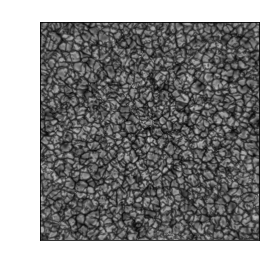

In [2]:
'''
IMPLEMENT CANNED SCI-KIT ALGORITHMS
see https://scikit-learn.org/stable/modules/clustering.html

Pick algorithms that are scalable to large n
These algorithms take
    data -> (n_samples, n_features) 
Features
    Pixel value 
    Other features, for example derived from sklearn.feature_extraction  
'''

# Plot data for comparison
plt.figure()
plt.imshow(data, cmap='gray', origin='lower')
plt.title('Initial data', color='white')
plt.tick_params(labelcolor='white', color='white')

# Prep data
x_size = np.shape(data)[0]
y_size = np.shape(data)[1]
data_flat = np.reshape(data, (x_size * y_size, 1))

# # 1) KMeans ############################################################################
# #
# #       Unsupervised algorithm
# #       Groups obs into n_clusters based on proximity in feature space
# #       Overall, this seems to overestimate IGM
# #       3 clusters goes off the rails, does not ID fac

# from sklearn.cluster import KMeans

# n_clusterss = [2, 3]
# inits = ['k-means++', 'random'] # can also try passing locs of centers if use another alg to determine

# dict = {}
# i = 0
# for n_clusters in n_clusterss:
#     for init in inits:
#         labels_flat = KMeans(n_clusters=n_clusters, init=init).fit(data_flat).labels_
#         labels = np.reshape(labels_flat, (x_size, y_size))
#         dict[str(i)] = [n_clusters, init, labels]
#         i += 1

# fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 10))
# fig.suptitle('KMeans', color='white')
# axs = [ax1, ax2, ax3, ax4]
# for i in range(len(axs)):
#     n_clusters =  dict[str(i)][0]
#     init = dict[str(i)][1]
#     labels = dict[str(i)][2]
#     axs[i].imshow(labels, origin='lower')
#     axs[i].set_title('n_clusters='+str(n_clusters)+', init='+str(init), color='white')

# for ax in axs:
#     ax.tick_params(labelcolor='white', color='white')


# # 2) AgglomorativeCluster ################################################################
# #
# #       Unsupervised algorithm
# #       Groups obs into n_clusters based on 
# #       NOT ABLE TO GET WORKING - I belive this should be scalable so why do I get MemoryError: Unable to allocate 77.9 TiB for an array with shape (10703266665840,) and data type float64?

# from sklearn.cluster import AgglomerativeClustering

# n_clusterss = [2]
# metrics = ['euclidean', 'li', 'manhattan']
# linkages = ['ward', 'complete', 'average']

# dict = {}
# i = 0
# for n_clusters in n_clusterss:
#     for metric in metrics:
#         for linkage in linkages:
#             labels_flat = AgglomerativeClustering(n_clusters=n_clusters, affinity=metric, linkage=linkage).fit(data_flat).labels_
#             labels = np.reshape(labels_flat, (x_size, y_size))
#             dict[str(i)] = [n_clusters, metric, linkage, labels]
#             i += 1

# fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, figsize=(15, 15))
# fig.suptitle('AgglomerativeClustering', color='white')
# axs = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]
# for i in range(len(axs)):
#     n_clusters =  dict[str(i)][0]
#     metric = dict[str(i)][1]
#     linkage = dict[str(i)][2]
#     labels = dict[str(i)][3]
#     axs[i].imshow(labels, origin='lower')
#     axs[i].set_title('n_clusters='+str(n_clusters)+', metric='+str(metric)+', linkage='+str(linkage), color='white')

# for ax in axs:
#     ax.tick_params(labelcolor='white', color='white')



# # 3) DBSCAN ############################################################################
# #
# #       Unsupervised algorithm
# #       Groups obs into n_clusters based on 
# #       NOT ABLE TO GET WORKING - I belive this should be scalable so why do I get MemoryError?

# from sklearn.cluster import DBSCAN

# epss = [0.2, 0.5, 0.8]
# min_sampless = [4, 10]
# metric = 'euclidean'
# algorithm = 'auto'

# dict = {}
# i = 0
# for eps in epss:
#     for min_samples in min_sampless:
#         labels_flat = DBSCAN(eps=eps, min_samples=min_samples, metric=metric, algorithm=algorithm, n_jobs=3).fit(data_flat).labels_
#         labels = np.reshape(labels_flat, (x_size, y_size))
#         dict[str(i)] = [eps, min_samples, labels]
#         i += 1

# fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 2, figsize=(15, 10))
# fig.suptitle('DBSCAN', color='white')
# axs = [ax1, ax2, ax3, ax4]
# for i in range(len(axs)):
#     eps =  dict[str(i)][0]
#     min_samples = dict[str(i)][1]
#     labels = dict[str(i)][2]
#     axs[i].imshow(labels, origin='lower')
#     axs[i].set_title('eps='+str(eps)+', min_samples='+str(min_samples), color='white')

# for ax in axs:
#     ax.tick_params(labelcolor='white', color='white')


# 3) OPTICS ############################################################################
#
#       Unsupervised algorithm
#       Groups obs into n_clusters based on 

from sklearn.cluster import OPTICS

max_epss = [0.2, 0.5, 0.8]
min_sampless = [4, 10]
metric = 'euclidean'
algorithm = 'auto'

dict = {}
i = 0
for eps in max_epss:
    for min_samples in min_sampless:
        labels_flat = OPTICS(max_eps=eps, min_samples=min_samples, metric=metric, algorithm=algorithm).fit(data_flat).labels_
        labels = np.reshape(labels_flat, (x_size, y_size))
        dict[str(i)] = [eps, min_samples, labels]
        i += 1

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('OPTICS', color='white')
axs = [ax1, ax2, ax3, ax4]
for i in range(len(axs)):
    max_eps =  dict[str(i)][0]
    min_samples = dict[str(i)][1]
    labels = dict[str(i)][2]
    axs[i].imshow(labels, origin='lower')
    axs[i].set_title('max_eps='+str(max_eps)+', min_samples='+str(min_samples), color='white')

for ax in axs:
    ax.tick_params(labelcolor='white', color='white')


In [ ]:
# ATTEMPT RANDOM FOREST

# Flatten data
data1 =  data.reshape(-1) # flattened

# Initialize df of features
df = pd.DataFrame()
df['OG_value'] = data1

# Add values of different Gabor filters as features
num = 1
kernels = []
for theta in range(2):
    theta = theta/4 * np.pi
    for sigma in [1,3]:
        for lambd in np.arange(0, np.pi, np.pi/4):
            for gamma in [0.05, 0,5]:
                kernel = cv2.getGaborKernel((5, 5), sigma, theta, lambd, gamma, 0, ktype=cv2.CV_32F)
                kernels.append(kernel)
                filtered_img = cv2.filter2D(data1, cv2.CV_8UC3, kernel).reshape(-1)
                df['Gabor'+str(num)] = filtered_img
                num =  num + 1

# Add Canny edge detection as another feature
edges = cv2.Canny(data).reshape(-1)
df['Canny_edges'] = edges

# Add label column using our non-ML id method
path = "c:\\Users\\lea\\OneDrive\\DKISTSegmentation\\DKISTSegmentation\\example_outputs\\DKIST\\segmented_data_DKIST_example.fits"
labels = fits.open(path)[0].data.reshape(-1) # flattened
df['labels'] =  labels

# Make cleaner X and Y and seperate training and test sets
X =  df.drop(labels =["labels"], axis=1)
Y = df['labels']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=20)

# Train RF classifier on this data
model =  RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, Y_train)

# Predict on test set
predictions =  model.predict(X_test)
print('Accuracy on test set: ', metrics.accuracy_score(Y_test, predictions))

error: OpenCV(4.7.0) D:/a/opencv-python/opencv-python/opencv/modules/imgproc/src/filter.simd.hpp:3232: error: (-215:Assertion failed) cn == CV_MAT_CN(dstType) && ddepth >= sdepth in function 'cv::opt_AVX2::getLinearFilter'


In [43]:
seg_data =  fits.open("c:\\Users\\lea\\OneDrive\\DKISTSegmentation\\DKISTSegmentation\\example_outputs\\DKIST\\segmented_data_DKIST_example.fits")

# print(seg_data[0].data)
# plt.imshow(seg_data[0].data)
# plt.figure()
# plt.imshow(seg_data[1].data)

In [40]:
flat = data.flatten()
# plt.hist(flat, bins=20, label='DKIST')

import scipy.io as sio
IBIS = sio.readsav("c:\\Users\\lea\\OneDrive\\DKISTSegmentation\\DKISTSegmentation\\data\\IBIS\\IBIS_example.sav")
IBIS = IBIS['rosa_gband']
flat = IBIS.flatten()
# plt.hist(flat, bins=20, label='IBIS rosa_gband')

# plt.xlabel('intensity', color='white')
# plt.tick_params(labelcolor='white', color='white')
# plt.legend()